## Tarea 1: Repaso básicos de ML — material de práctica (no calificado)

Esta tarea **ya no se entrega ni se califica**. Es material de práctica y preparación: los exámenes evalúan la teoría detrás de estos experimentos (temarios en `Examenes/`) y el proyecto de colaboración con IA usa este mismo protocolo experimental.

Sugerencias para sacarle provecho:
1. Puedes usar LLMs o agentes de IA libremente — de hecho es buen entrenamiento para el proyecto final. Pero recuerda: los exámenes son en clase y a mano, evalúan que *tú* entiendas.
2. Antes de correr cada experimento, escribe qué esperas observar y por qué; después compara con lo que obtuviste.
3. Asegúrate de entender cada línea del código (tuyo o del agente); consulta la documentación de PyTorch.
4. Mantén el protocolo experimental del curso: semilla fija, mismos splits, un factor variado a la vez, curvas + tabla resumen + interpretación.

Las siguientes preguntas son de implementación utilizando el notebook que tenemos de Intro_Pytorch. 

1. Regresión lineal desde cero: 

    a. Define un modelo lineal utilizando `nn.Linear(1,1)` y entrena utilizando la función `synthetic_regression_data` del notebook

    b. Con los mismo datos, define un modelo utilizando la `LinearRegression` que nosotros generamos

    c. Compara los resultados que generan estas dos. ¿Cuál es la diferencia? 

2. Batch vs. Minibatch:
    
    a. Entrena con `batch_size = n` (el ejemplo del notebook) con batch_size = 16, 32  y 64

    b. Grafica la pérdida por época en los tres casos y comenta las diferencias en estabilidad y velocidad de convergencia.

3. Closed-form vs. GD:
    
    a. Usa `torch.linalg.lstsq` o la fórmula cerrada para obtener w y b

    b. Compara sus valores con los aprendidos por GD tras converger (misma escala y ruido).

4. Decay de la learning rate:

    a. Usa `torch.optim.lr_scheduler.StepLR` con step = 100 epochs, γ = 0.1.
    b. Registra la lr en cada época y muéstrala junto a la pérdida para ver el efecto del decaimiento.

## Ejercicio 1

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

#### A mano

In [13]:
def synthetic_regression_data(w, b, num_samples = 1000):
    
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1, 1) + b
    y += torch.randn_like(y) * 0.01

    return X, y

In [14]:
true_w = torch.tensor([2.0])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)

In [15]:
class LinearRegression(nn.Module):
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super(LinearRegression, self).__init__()

        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma

        self.w =  nn.Parameter(
            torch.normal(0.0, sigma, size = (num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, X):

        return torch.matmul(X, self.w) + self.b

    def loss(self, y_hat, y):

        l = (y_hat - y)**2 / 2

        return l.mean()

    def configure_optimizers(self):

        return SGD([self.w, self.b], self.lr)

In [16]:
class SGD:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
    
    def step(self):
        for p in self.params:
            p.data -= self.lr * p.grad
    
    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

In [17]:
dataset =  TensorDataset(X, y)

train_size = int(0.8 * len(dataset))
val_size =  len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [18]:
batch_size = 32

train_loader = DataLoader (train_dataset, batch_size = batch_size, shuffle = True)
val_loader =  DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

In [19]:
model = LinearRegression(num_inputs = X.shape[1], lr = 0.03)
optim = model.configure_optimizers()

Error en w:  tensor([0.0008])
Error en b:  tensor([0.0020])


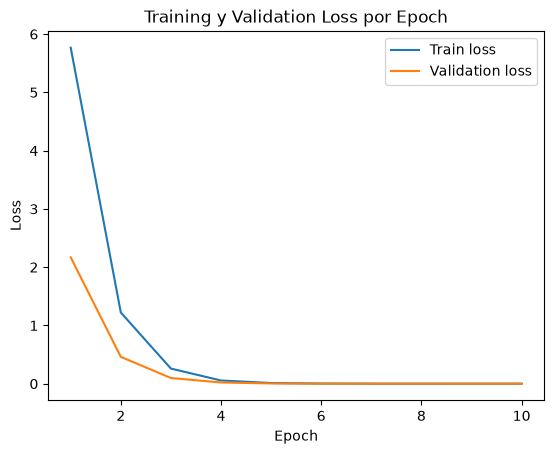

In [20]:
num_epochs = 10

train_losses, val_losses = [], []

for epoch in range(1, num_epochs +1):
    # Fase de entrenamiento
    model.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model(Xb)
        loss = model.loss(y_hat, yb)
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]

    train_losses.append(total_train / count_train)

    # Fase de  validación
    model.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = model.loss(model(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]

    val_losses.append(total_val / count_val)

# Evaluación final de los parámetroos aprendidos 

with torch.no_grad():
    est_w = model.w.reshape(true_w.shape)
    est_b = model.b
    print("Error en w: ", true_w - est_w)
    print("Error en b: ", true_b - est_b)

# Graficar pérdidas
plt.plot(range(1, num_epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch')
plt.show()

#### Usando `nn.Linear`

In [21]:
model_nn = nn.Linear(in_features = X.shape[1], out_features = 1)
optim_nn = torch.optim.SGD(model_nn.parameters(), lr = 0.03)
loss_fn = nn.MSELoss()

Error en w:  tensor([0.0002])
Error en b:  tensor([1.4782e-05])


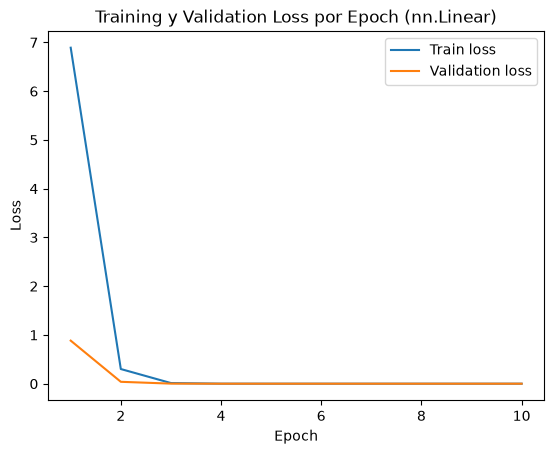

In [22]:
num_epochs = 10

train_losses_nn, val_losses_nn = [], []

for epoch in range(1, num_epochs + 1):
    model_nn.train()
    total_train, count_train = 0.0, 0
    for Xb, yb in train_loader:
        y_hat = model_nn(Xb)
        loss = loss_fn(y_hat, yb)
        optim_nn.zero_grad()
        loss.backward()
        optim_nn.step()
        total_train += loss.item() * yb.shape[0]
        count_train += yb.shape[0]

    train_losses_nn.append(total_train / count_train)

    model_nn.eval()
    total_val, count_val = 0.0, 0
    with torch.no_grad():
        for Xv, yv in val_loader:
            loss_val = loss_fn(model_nn(Xv), yv)
            total_val += loss_val.item() * yv.shape[0]
            count_val += yv.shape[0]

    val_losses_nn.append(total_val / count_val)


with torch.no_grad():
    est_w = model_nn.weight.reshape(true_w.shape)
    est_b = model_nn.bias

    print("Error en w: ", true_w - est_w)
    print("Error en b: ", true_b - est_b)

plt.plot(range(1, num_epochs + 1), train_losses_nn, label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses_nn, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training y Validation Loss por Epoch (nn.Linear)')
plt.show()    